In [ ]:
# importing different modules
# numpy is for math and matrix/vector stuff
# matplotlib is for visualizing data
# PIL allows for opening image files
# torchvision and torch are for ML handling
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.transforms import v2
import torchvision.models as models
import torch
import pandas as pd

# os and sys allow us to do stuff with files
import os
import sys

In [12]:
## taken from pytorch forums
# creates an array of class labels where idx2label[i] is the string label associated with class i
import json
class_idx = json.load(open("imagenet_class_index.json"))
idx2label = np.array([class_idx[str(k)][1] for k in range(len(class_idx))])
#print(idx2label)
def convertIndexToLabel(i):
    return idx2label[i]

# using the imagenet official correct validation classifications, turns those class numbers into a list of classification names
# these are the "correct" classes for each image in the dataset
file_path = 'val.txt'
true_class_nums = np.loadtxt(file_path, dtype = int)
true_class_names = convertIndexToLabel(true_class_nums)

In [13]:

# Defining the different models, using pretrained weights
alexnet = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
resnet = models.resnet34(weights = models.ResNet34_Weights.DEFAULT)
convnext = models.convnext_base(weights = models.ConvNeXt_Base_Weights.DEFAULT)


# Setting the models to evaluation mode
alexnet.eval()
resnet.eval()
convnext.eval()

# Get the preprocessing transformations necessary in order for the models to take the image inputs
alex_preprocess = models.AlexNet_Weights.DEFAULT.transforms()
res_preprocess = models.ResNet34_Weights.DEFAULT.transforms()
conv_preprocess = models.ConvNeXt_Base_Weights.DEFAULT.transforms()


# setup that allows us to iterate through the different models
class modelinfo:
    def __init__(self, model, preprocess):
        self.name = model._get_name()
        self.model = model
        self.preprocess = preprocess
alexinfo = modelinfo(alexnet, alex_preprocess)
resinfo = modelinfo(resnet, res_preprocess)
convinfo = modelinfo(convnext, conv_preprocess)
used_models = [alexinfo, resinfo, convinfo]

In [20]:
# loads an image and transforms it to the correct input format for the given model
# set save_images to false if running on a large dataset, or if you don't want to view the images at the end
def load_image (filename, model, save_images):
    img = Image.open("imagenet_val_dataset/"+filename)
    #img_np = np.array(img)
    #img.convert("RGB") is important because some images are in black-and-white,
    #which means they have a different tensor size as colored images, since they 
    #are missing a color channel
    input = model.preprocess(img.convert("RGB")).unsqueeze(0)
    #converts the image to a numpy array so we can view it with matplotlib.
    img_np = None
    if save_images:
        img_np = input.numpy()
    return input, img_np

# Loads and adds gaussian noise to the input image. noiseparams is (mean, standard deviation) for the gaussian noise.
def load_image_noise(filename, model, save_images, noiseparams):
    mean, stdev = noiseparams
    # loads the image
    pre_noise, _ = load_image(filename, model, False)
    
    # uses torchvision gaussian noise function to add gaussian noise to the image
    # noise_func is actually a function
    noise_func = v2.GaussianNoise(mean, stdev)
    # we then run the function on the pre-noise tensor, to get a tensor with the noise added
    input = noise_func(pre_noise)

    # code to save images
    img_np = None
    if save_images:
        img_np = input.numpy()
    return input, img_np

# given a single preprocessed input tensor and a trained model, predicts a label for the input image
def inference_single_image (input, model):
    # gets the "probability" for each class
    prob = torch.nn.functional.softmax(model.model(input)[0], dim=0)
    # sorts the class labels in order from highest to lowest "probability"
    sorted_prob_label = sorted(zip(prob, idx2label), reverse = True)
    sorted_prob, sorted_label = zip(*list(sorted_prob_label))
    # gets the predicted label
    label = sorted_label[0]
    # adds a copy of the image so we can display alongside data below
    return label

def load_image (filename, model):
    img = Image.open("imagenet_val_dataset/"+filename)
    #img_np = np.array(img)
    #img.convert("RGB") is important because some images are in black-and-white,
    #which means they have a different tensor size as colored images, since they 
    #are missing a color channel
    input = model.preprocess(img.convert("RGB")).unsqueeze(0)
    img_np = input.numpy()
    return input, img_np

# adds gaussian noise to the input image. Noiseparams is (mean, standard deviation) for the gaussian noise.
def load_image_noise(filename, model, noiseparams):
    mean, stdev = noiseparams
    pre_noise, _ = load_image(filename, model)
    noise_func = lambda x: x + torch.randn_like(x) * stdev + mean
    input = noise_func(pre_noise)

    img_np = input.numpy()
    return input, img_np

In [21]:

# Runs all the images from start to num_iter through the model
# it will then add the labels, and images (as numpy array) to associated arrays for further analysis
def inference(misclassified_file, model, preprocess, save_images = False, num_iter = float('inf')):
    model_np_imgs = []

    # reads the lines from the file of misclassified images to get their names
    with open(misclassified_file, 'r') as listfile:
        misclassified_list = [line.rstrip() for line in listfile]
    
    print(model.name)
    labels = []
    count = 0

    # iterates through the misclassified images, and runs inference on them
    for file in misclassified_list:

        # allows code to end early if not running on full dataset (for testing purposes)
        if count == num_iter:
            break
        
        # running the files through the model
        if file[-5:] == ".JPEG":
            # code for making countdown
            print(f"\r{count+1}/{min(num_iter, len(misclassified_list))}", end="")
            sys.stdout.flush()
            count += 1
            # preprocesses the images. preprocess is actually a parameter, 
            # so we can pass it the noise function, a clean load image function, 
            # or any other image transformation function and it will all work, as long
            # as it takes the parameters (file, model, save_images) (see below about noise parameters)
            input, img_np = preprocess(file, model, save_images)
            # runs inference on the processed image
            label = inference_single_image(input, model)

            # code for saving labels/images
            if img_np is not None:
                model_np_imgs.append(img_np)
            labels.append(label)

    
    print("")
    return labels, model_np_imgs

In [22]:
alex_labels, alex_imgs = inference("misclassified_images_by_class/AlexNet", alexinfo, load_image, True, 10)


AlexNet
10/10


In [23]:
# code to display multiple images in a grid
def display_images(images):
    size = int(np.ceil(np.sqrt(len(images))))
    fig, axes = plt.subplots(size, size, figsize = (10,10) )
    for i, img in enumerate(images):
        #print("blah")
        #img_np = img.transpose(1,2,0)
        row = i//size
        col = i%size
        axes[row][col].imshow(img[0].transpose(1,2,0))
        axes[row][col].axis('off')
    plt.tight_layout
    plt.show

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384109..1.9776908].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..1.907974].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.395991

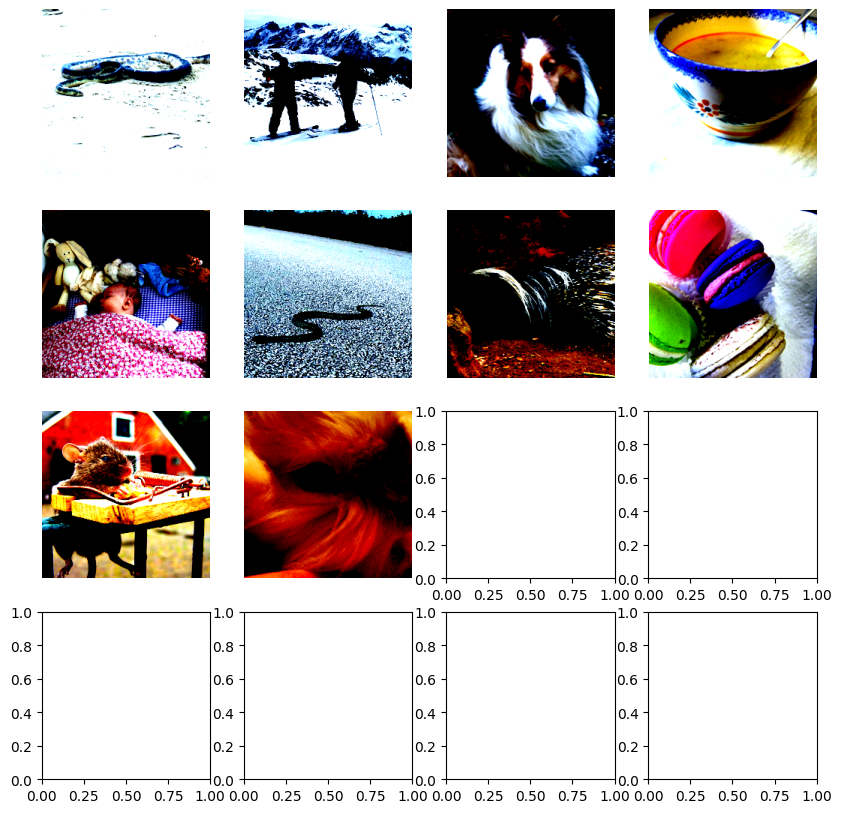

In [24]:
display_images(alex_imgs)

AlexNet
10/10


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.748607..2.2918117].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3182745..2.6767387].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3385572..2.860857].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.997488..2.6977499].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2185524..2.5129945].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0307107..2.047002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1649308..2

['leatherback_turtle', 'ski', 'Shetland_sheepdog', 'cup', 'beagle', 'diamondback', 'porcupine', 'bath_towel', 'fox_squirrel', 'Maltese_dog']
['leatherback_turtle', 'ski', 'Shetland_sheepdog', 'cup', 'beagle', 'diamondback', 'porcupine', 'bath_towel', 'frilled_lizard', 'hamster']


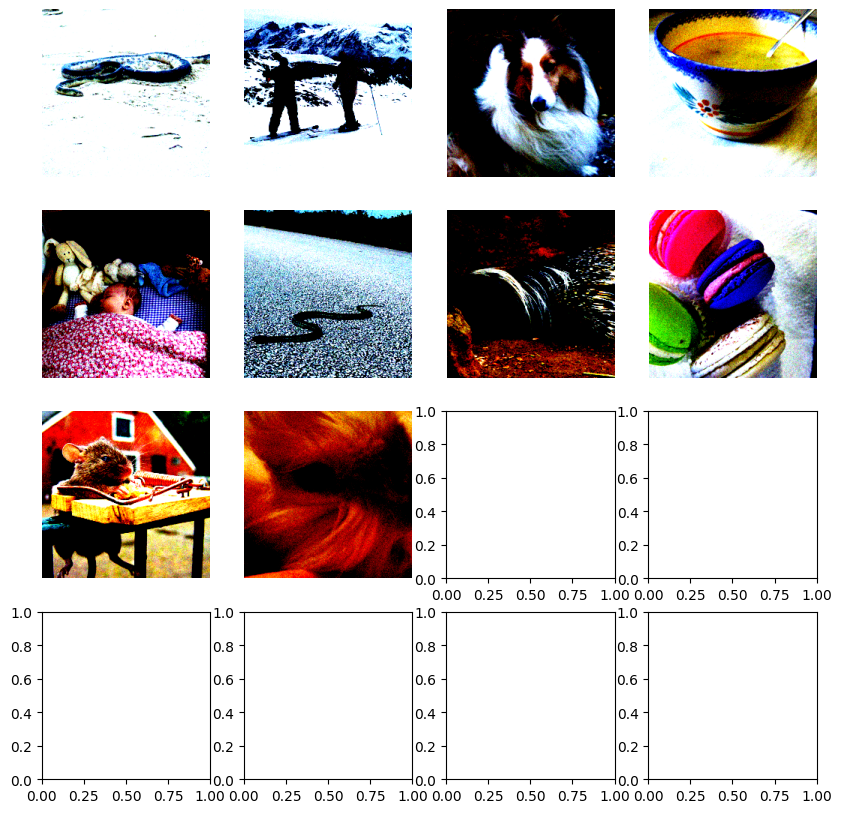

In [25]:
# because we are passing the noise preprocessing function to inference, but load_image_noise has extra parameters that inference does not give,
# we use functools partial to essentially "set" noiseparams to (0,0.1), so inference can ignore those parameters and still work.
from functools import partial
testNoise = partial(load_image_noise, noiseparams=(0, 0.1))

# runs inference on the AlexNet misclassified images with added noise
noise_alex_labels, noise_alex_imgs = inference("misclassified_images_by_class/AlexNet", alexinfo, testNoise, True, 10)
# displays the images and prints the labels side-by-side for comparison
display_images(noise_alex_imgs)
print(alex_labels)
print(noise_alex_labels)

In [26]:
alex_labels = inference("misclassified_images_by_class/AlexNet", alexinfo, load_image, True, 10)
res_labels = inference("misclassified_images_by_class/ResNet", resinfo, load_image, True, 10)
next_labels = inference("misclassified_images_by_class/ConvNeXt", convinfo, load_image, True, 10)

AlexNet
100/100
ResNet
100/100
ConvNeXt
100/100


In [ ]:
def load_results_csv_single_noise(misclass_images_file, true_class_names,  model_labels, noise_params, model_noise_labels, csv_filename):
    df = pd.DataFrame({"file_name": pd.Series(dtype='str'), 
                       "correct_class": pd.Series(dtype='str'), 
                       "predicted_class": pd.Series(dtype='str'),
                       "noise_params": pd.Series(),
                       "noise_predicted_class": pd.Series(dtype='str'),
                       })
    with open(misclass_images_file, 'r') as listfile:
        misclassified_list = [line.rstrip() for line in listfile]
    for i in range(len(model_noise_labels)):
        #print()
        image_num = int(misclassified_list[i][-13:-5])
        #print(image_num)
        df.loc[len(df)] = [misclassified_list[i], true_class_names[image_num-1], model_labels[i], noise_params, model_noise_labels[i]]
    df.to_csv(csv_filename)
    return df

In [22]:
load_results_csv_single_noise("misclassified_images_by_class/AlexNet", true_class_names,  alex_labels, (0, 0.1), noise_alex_labels, "csv_data/test_alex_noise.csv")


1

2

4

5

6

8

9

10

17

18
